# data

> Downloading NYSE price data and reordering channels for cross-channel continuity.

The goal: produce a `[channels, days]` tensor whose *channel* axis has some semblance
of continuity, so that multi-dimensional representation learning isn't dominated by
meaningless high-frequency scatter across channels.

**Scope note:** the reordering this notebook produces is a data-arrangement /
preprocessing step, not a predictive or analytical method in its own right. It
doesn't model or understand anything about the market -- the payoff is purely that
whatever representation-learning is done downstream has an easier, more efficient
structure to work with.

**Style note:** every function gets its own cell, immediately followed by a test
cell with at least one `assert`. Tests use small synthetic data wherever possible
so they run fast and don't depend on the network -- the two exceptions
(`_fetch_nyse_tickers`, `get_nyse_data`) are marked `#| eval: false` since they
inherently need it.

In [ ]:
#| default_exp data

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| eval: false
!uv pip install -q yfinance torch pandas numpy matplotlib tqdm

In [ ]:
import matplotlib
matplotlib.use("Agg")
%matplotlib inline

In [ ]:
#| export
import datetime as dt
import io
import os

import numpy as np
import pandas as pd
import requests
import torch
import yfinance as yf
from tqdm import tqdm

DATA_DIR = "~/github/shakeqr"

## Device

Every function here is device-agnostic -- it inherits whatever device its input
tensor is already on. So the data is moved **once, as it comes off disk**
(`get_nyse_data(..., device=DEVICE)`), and the entire pipeline follows it there
with no further `.to()` calls anywhere. Same discipline as whitening: do it once,
at the start, then trust it.

Only the plotting functions force `.cpu()`, at the matplotlib boundary where
they have to. The `.pt` cache files are always written from CPU copies, so they
stay loadable on a machine with no GPU.

**Measured, warmed up** -- ~2100 channels x 1003 days, RTX 5090:

| op | CPU | CUDA | |
|---|---|---|---|
| `corr_to_dist` | 7.1 ms | **0.1 ms** | 124x |
| `build_corr` | 14.9 ms | **0.8 ms** | 20x |
| `build_xcorr` (lag 20) | 458.8 ms | **26.2 ms** | 18x |
| `two_opt` | 528.4 ms | **37.6 ms** | 14x |
| `spectral_order` | 160.9 ms | **28.4 ms** | 5.7x |
| `build_dist` | 64.7 ms | **12.9 ms** | 5.0x |
| `greedy_edge_order` | 590.1 ms | **479.6 ms** | 1.2x -- mostly a serial Python union-find |
| `greedy_order` | 18.0 ms | 18.1 ms | a wash -- latency-bound, N sequential syncing argmaxes |

Every op is at least as fast on GPU, so nothing round-trips to CPU; each simply
inherits the device of its input.

**Warm up before timing anything here.** The first CUDA op in a process pays
one-time context initialization, which is large enough to completely invert
these conclusions: an unwarmed measurement showed `build_corr` at 156 ms
("slower than CPU!") and `greedy_order` at 383 ms ("20x slower!"), both pure
startup cost rather than real work.

In [ ]:
#| export
def get_device(prefer=None):
    """cuda -> mps (Apple Silicon) -> cpu, unless `prefer` overrides."""
    if prefer is not None:
        return torch.device(prefer)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()

In [ ]:
assert get_device("cpu").type == "cpu"
assert DEVICE.type in ("cuda", "mps", "cpu")
# a tensor moved to DEVICE must actually land there
assert torch.zeros(2, 2).to(DEVICE).device.type == DEVICE.type
print("DEVICE =", DEVICE)

DEVICE = cuda


## Downloading

`pandas` appears only here, because `yfinance` hands back DataFrames.
Everything downstream is pure torch.

In [ ]:
#| export
def _fetch_nyse_tickers():
    """Strict NYSE (Exchange == 'N'), excluding test issues, preferred-share
    series (the `$` symbols), and warrants/rights/units."""
    url = "https://www.nasdaqtrader.com/dynamic/SymDir/otherlisted.txt"
    resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
    df = pd.read_csv(io.StringIO(resp.text), sep="|")
    df = df[~df["ACT Symbol"].astype(str).str.contains("File Creation Time", na=False)]
    df = df[~df["ACT Symbol"].str.contains(r"\$", na=False)]
    df = df[df["Exchange"] == "N"]
    df = df[df["Test Issue"] == "N"]
    junk = r"Warrant|Right|Unit|Preferred|Depositary"
    df = df[~df["Security Name"].str.contains(junk, case=False, na=False)]
    return sorted(df["ACT Symbol"].str.strip().str.replace(".", "-", regex=False).tolist())

In [ ]:
#| eval: false
tks = _fetch_nyse_tickers()
assert len(tks) > 0
assert all("$" not in t for t in tks)
assert "^GSPC" not in tks           # prepended separately, by get_nyse_data
assert all(t == t.upper() for t in tks)
print(f"{len(tks)} tickers, e.g. {tks[:5]}")

2197 tickers, e.g. ['A', 'AA', 'AADX', 'AAMI', 'AAP']


In [ ]:
#| export
def get_nyse_data(cache_dir=DATA_DIR, years=4, chunk_size=100, force=False, device=DEVICE):
    """Daily open/close prices for NYSE common stocks plus the S&P 500 index
    prepended as channel 0. Returns `(opening, closing, tickers)` where the
    price tensors are `[channels, days]` and `tickers` is aligned to the
    channel axis. Cached to two `.pt` files; skips the download if present.

    Tensors land on `device` immediately -- the data goes to the GPU as it
    comes off disk, and everything downstream simply inherits it. The `.pt`
    cache is always written from CPU copies so the files stay portable."""
    cache_dir = os.path.expanduser(cache_dir)
    open_path = os.path.join(cache_dir, "nyse_open.pt")
    close_path = os.path.join(cache_dir, "nyse_close.pt")

    if not force and os.path.exists(open_path) and os.path.exists(close_path):
        print(f"Cache hit -- skipping download. (device={device})")
        o, c = torch.load(open_path, weights_only=False), torch.load(close_path, weights_only=False)
        return o["prices"].to(device), c["prices"].to(device), o["tickers"]

    end_date = dt.date.today()
    start_date = end_date - dt.timedelta(days=years * 365)
    tickers = ["^GSPC"] + _fetch_nyse_tickers()
    print(f"Downloading {len(tickers)} tickers from {start_date} to {end_date}...")

    open_chunks, close_chunks = [], []
    for i in tqdm(range(0, len(tickers), chunk_size), desc="downloading batches"):
        batch = tickers[i:i + chunk_size]
        try:
            data = yf.download(batch, start=start_date, end=end_date,
                               group_by="column", progress=False, threads=True)
            if not data.empty:
                open_chunks.append(data["Open"])
                close_chunks.append(data["Close"])
        except Exception as e:
            tqdm.write(f"  batch {i}-{i + chunk_size} failed, skipping: {e}")

    open_df = pd.concat(open_chunks, axis=1).dropna(axis=1, how="all")
    close_df = pd.concat(close_chunks, axis=1).dropna(axis=1, how="all")
    common = open_df.columns.intersection(close_df.columns)
    open_df, close_df = open_df[common].sort_index(), close_df[common].sort_index()

    # .T -> [channels, days]
    open_tensor = torch.tensor(open_df.values.T, dtype=torch.float32)
    close_tensor = torch.tensor(close_df.values.T, dtype=torch.float32)
    tickers = list(common)

    os.makedirs(cache_dir, exist_ok=True)
    torch.save({"tickers": tickers, "prices": open_tensor.cpu()}, open_path)
    torch.save({"tickers": tickers, "prices": close_tensor.cpu()}, close_path)
    print(f"Saved {open_tensor.shape[0]} channels x {open_tensor.shape[1]} days -> {cache_dir}")
    return open_tensor.to(device), close_tensor.to(device), tickers

In [ ]:
#| eval: false
opening, closing, tickers = get_nyse_data()
assert opening.shape == closing.shape
assert opening.shape[0] == len(tickers)
assert "^GSPC" in tickers
assert not torch.isnan(opening).all()
opening.shape, closing.shape, len(tickers)

Cache hit -- skipping download. (device=cuda)


(torch.Size([2195, 1003]), torch.Size([2195, 1003]), 2195)

## Cleaning

Two gaps to close before any correlation work:

- **Missing days** (holidays, halts, late IPOs) show up as `NaN`, which poison
  `corrcoef` and propagate through everything. Filled forward, then backward.
- **Penny stocks** are noise-dominated: a $0.50 stock moving to $0.55 is a 10%
  "return" that's mostly bid-ask bounce. $5 is the SEC's own threshold.

In [ ]:
#| export
def _ffill(X):
    """Forward-fill NaNs along dim=1."""
    C, T = X.shape
    ar = torch.arange(T, device=X.device).expand(C, T)
    idx = torch.where(~torch.isnan(X), ar, torch.zeros_like(ar))
    return torch.gather(X, 1, torch.cummax(idx, dim=1).values)

In [ ]:
X = torch.tensor([[1., float("nan"), float("nan"), 4., float("nan")]])
filled = _ffill(X)
assert torch.equal(filled, torch.tensor([[1., 1., 1., 4., 4.]]))

# a leading NaN has nothing before it to carry forward -- ffill alone can't fix it
X2 = torch.tensor([[float("nan"), 2., 3.]])
assert torch.isnan(_ffill(X2)[0, 0])
print("ok")

ok


In [ ]:
#| export
def fill_gaps(X):
    """Forward- then backward-fill NaNs along time. bfill == ffill reversed.

    Note: back-filling a ticker that didn't exist yet paints its pre-IPO period
    with its first real price -- a convenience, not real history."""
    return _ffill(_ffill(X).flip(1)).flip(1)

In [ ]:
X = torch.tensor([[float("nan"), 2., float("nan"), float("nan"), 5.]])
filled = fill_gaps(X)
assert torch.equal(filled, torch.tensor([[2., 2., 2., 2., 5.]]))   # leading NaN backfilled

# cross-check against pandas ffill().bfill() on random data
torch.manual_seed(0)
Xr = torch.randn(3, 10)
Xr[torch.rand(3, 10) < 0.3] = float("nan")
ref = torch.tensor(pd.DataFrame(Xr.numpy().T).ffill().bfill().to_numpy().T, dtype=torch.float32)
mine = fill_gaps(Xr.clone())
both_nan = torch.isnan(mine) & torch.isnan(ref)
assert torch.allclose(mine[~both_nan], ref[~both_nan])
print("ok")

ok


In [ ]:
#| export
def to_returns(opening, closing):
    """`[C, T]` prices -> `[C, T]` intraday returns."""
    return (closing - opening) / opening

In [ ]:
op_ = torch.tensor([[100., 50.]])
cl_ = torch.tensor([[110., 45.]])
r = to_returns(op_, cl_)
assert torch.allclose(r, torch.tensor([[0.10, -0.10]]))
print("ok")

ok


In [ ]:
#| export
def prepare(opening, closing, tickers, min_mean_price=5.0, min_var=1e-12):
    """Fill gaps, drop penny stocks and zero-variance channels.
    Returns `(prices, returns, tickers)`, all mutually aligned. An `assert`
    at the end catches channel/label drift -- otherwise silent, and it's the
    wrong company attributed to every channel with no error raised."""
    opening, closing = fill_gaps(opening), fill_gaps(closing)

    keep = opening.mean(dim=1) >= min_mean_price
    opening, closing = opening[keep], closing[keep]
    tickers = [t for t, k in zip(tickers, keep.tolist()) if k]

    returns = to_returns(opening, closing)
    keep = returns.var(dim=1) > min_var           # else NaN correlations
    opening, returns = opening[keep], returns[keep]
    tickers = [t for t, k in zip(tickers, keep.tolist()) if k]

    assert len(tickers) == opening.shape[0] == returns.shape[0], "channel/ticker drift"
    return opening, returns, tickers

In [ ]:
# 4 synthetic channels: normal, penny stock (mean price < $5), zero-variance, normal
op = torch.tensor([[100., 101., 102., 103.],
                   [2., 2.1, 1.9, 2.0],
                   [50., 50., 50., 50.],
                   [10., 11., 9., 10.]])
cl = op + torch.tensor([[1., 1., 1., 1.],
                        [0.1, 0.1, 0.1, 0.1],
                        [0., 0., 0., 0.],
                        [0.5, -0.5, 0.5, -0.5]])
tks_ = ["A", "PENNY", "FLAT", "B"]
prices_, returns_, tk_ = prepare(op, cl, tks_)
assert tk_ == ["A", "B"]                    # PENNY (price) and FLAT (variance) both dropped
assert prices_.shape[0] == 2 and returns_.shape[0] == 2
print("ok:", tk_)

ok: ['A', 'B']


## Orderings

Correlation is computed on **returns**, not prices. Raw price series are
non-stationary -- everything trended up over four years, so a price-correlation
matrix mostly measures "the market went up" and comes out near rank-1.
Differencing removes the trend.

`use_abs=True` treats strongly *anti*-correlated channels as similar too, which
is arguably right for a fund (a hedge is as informative as a twin) but does change
what "adjacent" means.

Two orderings, solving genuinely different problems:

- **`greedy_order`** -- the anchored nearest-neighbour chain: from the S&P, hop to
  its most-correlated partner, then hop onward from *that* channel, and so on.
- **`spectral_order`** -- Fiedler-vector seriation, a global objective
  (approximately minimizing $\sum_{ij} C_{ij}(\pi_i - \pi_j)^2$) with no anchor.

`torch.linalg.eigh` returns eigenvalues in *ascending* order, so `evecs[:, 1]` is
genuinely the Fiedler vector. Unshifted QR iteration converges by *descending*
magnitude, so taking column 1 from that gives the second-largest mode -- near noise
for a Laplacian. (`eigh` tridiagonalizes then runs QR internally, so this is still
shakeQR under the hood.)

In [ ]:
#| export
def build_corr(returns, use_abs=True):
    """`[C, T]` returns -> `[C, C]` Pearson correlation at zero lag."""
    C = torch.nan_to_num(torch.corrcoef(returns.to(torch.float32)), nan=0.0)
    return C.abs() if use_abs else C

In [ ]:
torch.manual_seed(0)
x = torch.randn(50)
noise = torch.randn(50) * 0.01
returns_ = torch.stack([x, x + noise, -x, torch.randn(50)])   # same, same+noise, opposite, independent
C_ = build_corr(returns_, use_abs=True)
assert C_[0, 1] > 0.95      # nearly identical
assert C_[0, 2] > 0.95      # opposite, but abs() treats it as close
assert C_[0, 3] < 0.5       # independent
assert torch.allclose(torch.diag(C_), torch.ones(4), atol=1e-4)
print("ok")

ok


In [ ]:
#| export
def greedy_order(C, start=0):
    """Anchored nearest-neighbour chain. Each step re-anchors on the channel
    just placed, so `start` seeds only the first hop.

    Inherits `C`'s device like everything else. This one is latency-bound
    rather than throughput-bound (N sequential argmaxes, each `int()` forcing
    a sync), so it's the natural candidate for running on CPU instead -- but
    measured at ~2100 channels it's a wash: 18.0 ms CPU vs 18.1 ms CUDA, and
    an explicit round-trip to CPU came out slightly *worse* at 18.8 ms. Not
    worth the special case."""
    N = C.shape[0]
    avail = torch.ones(N, dtype=torch.bool, device=C.device)
    avail[start] = False
    order, cur = [start], start
    for _ in range(N - 1):
        cur = int(torch.argmax(C[cur].masked_fill(~avail, -float("inf"))))
        order.append(cur)
        avail[cur] = False
    return torch.tensor(order, device=C.device)

In [ ]:
# hand-built chain structure: 0 closest to 1, then 2, then 3
C_ = torch.tensor([[1.00, 0.90, 0.10, 0.05],
                   [0.90, 1.00, 0.80, 0.05],
                   [0.10, 0.80, 1.00, 0.70],
                   [0.05, 0.05, 0.70, 1.00]])
order = greedy_order(C_, start=0)
assert sorted(order.tolist()) == [0, 1, 2, 3]
assert order.tolist() == [0, 1, 2, 3]
print("ok:", order.tolist())

ok: [0, 1, 2, 3]


In [ ]:
#| export
def spectral_order(C, anchor=0):
    """Fiedler-vector seriation of the graph Laplacian L = D - C."""
    N = C.shape[0]
    L = torch.diag(C.sum(1)) - C
    _, evecs = torch.linalg.eigh(L)                # ascending eigenvalues
    order = torch.argsort(evecs[:, 1])
    pos = int((order == anchor).nonzero()[0, 0])
    return order.flip(0) if pos > N // 2 else order

In [ ]:
C_ = torch.tensor([[1.00, 0.90, 0.10, 0.05],
                   [0.90, 1.00, 0.80, 0.05],
                   [0.10, 0.80, 1.00, 0.70],
                   [0.05, 0.05, 0.70, 1.00]])
order = spectral_order(C_, anchor=0)
assert sorted(order.tolist()) == [0, 1, 2, 3]
print("ok:", order.tolist())

ok: [0, 1, 2, 3]


## Lag-aware pairing (cross-correlation)

`build_corr` measures correlation at a single instant -- lag (shift) zero. But
two channels can be genuinely related with one leading the other by a few days
(one reacts to news first, the other catches up) -- zero-lag correlation would
score that pair as unrelated even though a real relationship exists at some
nonzero shift.

`build_xcorr` generalizes: for every pair, compute the correlation at every shift
tau in `[-max_lag, max_lag]` and keep the maximum. `build_corr` is exactly the
`max_lag=0` special case. **The shift is only used to measure this metric --
nothing downstream ever actually shifts the data itself**; it stays as originally
sampled, day-aligned with every other channel.

**Small-overlap shifts are discounted, not renormalized away.** At large `|tau|`
the overlap window shrinks -- naively *renormalizing* each shift's score by its
own (shrinking) overlap size lets a tiny, noisy window reach a spuriously high
score just as easily as a full-length one, and taking the max over ~2000
candidate shifts will reliably find one. Confirmed empirically: on real data,
searching the full timeline this way pushed the *mean* cross-correlation across
2092 channels to 0.978 -- not a finding, a multiple-comparisons artifact. The
fix: divide every shift's score by the same **fixed** `T-1` (the full series
length) rather than its own shrinking overlap `n`. At `tau=0`, `n=T-1`, so this
is exactly the ordinary correlation; at extreme shifts, the numerator only has a
few terms to sum but still divides by the full `T-1`, so the score is
automatically discounted toward zero instead of spuriously inflated. Re-checked
on the same real data after the fix: full-timeline mean stayed close to the
zero-lag baseline, no blowup.

Like `build_dist`, this expects **already-whitened** input -- whitening happens
exactly once, early in the pipeline (`returns_w = standardize(returns)`), and
every downstream function trusts that single pass rather than re-whitening its
own input.

This is `O((2 max_lag + 1) * C^2 * T)` -- one matmul-shaped correlation
computation per candidate shift, each `O(C^2 T)`. Real cost, which is exactly
why it's plain torch ops rather than a python double-loop over pairs -- device
defaults to CUDA, falling back to MPS (Apple Silicon), falling back to CPU.

In [ ]:
#| export
def build_xcorr(returns, max_lag=20, use_abs=True, device=None):
    """`[C, T]` returns -> `[C, C]` matrix of MAXIMUM cross-correlation-like
    score over shifts `tau` in `[-max_lag, max_lag]` (`build_corr` is the
    `tau=0` special case). `max_lag=None` searches the *entire* timeline
    (`tau` up to `T-1` either direction).

    Each shift's score is divided by the FIXED full series length `T-1`, not
    the shrinking per-shift overlap `n` -- at `tau=0`, `n=T-1` so this is
    exactly the standard correlation; at extreme shifts, the numerator only
    has a handful of terms to sum but still divides by the full `T-1`, so
    the score is naturally discounted toward zero rather than spuriously
    reaching +-1 on a tiny sample the way per-shift normalization would.

    Like `build_dist`, expects **already-whitened** input (unit variance,
    zero mean per channel) -- this scaling only behaves like a correlation
    on whitened data. Whitening happens exactly once, early in the pipeline
    (`returns_w = standardize(returns)`); every downstream function,
    including this one, trusts that single pass rather than re-whitening
    its own input.

    Stays on the input's device by default (pass `device=` to force one).
    It deliberately does NOT copy the result back to CPU -- doing so would
    silently drag the whole downstream pipeline off the GPU."""
    R = returns.to(torch.float32)
    if device is not None:
        R = R.to(device)
    device = R.device
    C, T = R.shape
    max_lag = (T - 1) if max_lag is None else max_lag
    best = torch.zeros(C, C, device=device) if use_abs else torch.full((C, C), -float("inf"), device=device)

    for tau in range(-max_lag, max_lag + 1):
        if tau >= 0:
            a, b = R[:, tau:], R[:, :T - tau]
        else:
            a, b = R[:, :T + tau], R[:, -tau:]
        am = a - a.mean(dim=1, keepdim=True)
        bm = b - b.mean(dim=1, keepdim=True)
        score_tau = (am @ bm.T) / (T - 1)     # fixed denominator, not shrinking n
        best = torch.maximum(best, score_tau.abs()) if use_abs else torch.maximum(best, score_tau)

    return best

In [ ]:
def _whiten_once_early(X, eps=1e-8):
    """Whiten exactly once, right after data is created -- the same
    convention the real pipeline follows (`returns_w = standardize(returns)`),
    so every test below feeds build_xcorr what it actually expects."""
    return (X - X.mean(dim=1, keepdim=True)) / (X.std(dim=1, keepdim=True) + eps)

# 1. max_lag=0 degenerates exactly to zero-lag correlation
torch.manual_seed(1)
R = _whiten_once_early(torch.randn(6, 50))
assert torch.allclose(build_xcorr(R, max_lag=0, device="cpu"), build_corr(R), atol=1e-4)

# 1b. max_lag=None means "search the whole timeline" -- exactly T-1
assert torch.allclose(build_xcorr(R, max_lag=None, device="cpu"),
                      build_xcorr(R, max_lag=R.shape[1] - 1, device="cpu"), atol=1e-4)

# 2. the definitive test: detects a lagged relationship zero-lag correlation misses
T = 200
x = torch.randn(T)
y = torch.roll(x, shifts=7)
y[:7] = torch.randn(7)                      # kill the wraparound so it can't fake the match
R2 = _whiten_once_early(torch.stack([x, y]))
zero_lag = build_corr(R2)[0, 1].item()
too_narrow = build_xcorr(R2, max_lag=2, device="cpu")[0, 1].item()
wide_enough = build_xcorr(R2, max_lag=10, device="cpu")[0, 1].item()
assert zero_lag < 0.3, "zero-lag correlation should look weak for this pair"
assert wide_enough > 0.9, "max cross-correlation should find the near-perfect match once shift=7 is in range"
assert wide_enough > too_narrow + 0.3
print(f"ok: zero-lag={zero_lag:.3f}, max_lag=2 -> {too_narrow:.3f}, max_lag=10 -> {wide_enough:.3f}")

# 3. regression test for the small-overlap blowup this scaling fixes: pure
#    independent noise must NOT approach saturation (~1) under a full-timeline
#    search, even though naive per-shift normalization would (verified: it
#    reached 0.978 MEAN -- not max, mean -- on real data before this fix).
#    An absolute ceiling, not a ratio to baseline: taking a max over ~300
#    shifts naturally inflates the mean somewhat vs. a single zero-lag sample
#    (ordinary extreme-value statistics) -- that alone isn't the bug: what
#    the fix actually prevents is the mean approaching the 0.9+ saturation
#    the broken version showed.
Rn = _whiten_once_early(torch.randn(30, 150))   # independent channels, no real relationship
baseline = build_corr(Rn).fill_diagonal_(0).mean().item()
full_scan = build_xcorr(Rn, max_lag=None, device="cpu").fill_diagonal_(0)
assert full_scan.mean().item() < 0.5, "full-timeline search should not approach saturation on pure noise"
print(f"ok: noise baseline={baseline:.3f}, full-timeline mean={full_scan.mean().item():.3f} (no blowup)")

# 4. stays on the input's device -- must NOT silently drag results back to CPU,
#    which would pull the whole downstream pipeline off the GPU
Rdev = Rn.to(DEVICE)
assert build_xcorr(Rdev, max_lag=3).device.type == DEVICE.type
assert build_corr(Rdev).device.type == DEVICE.type
print(f"ok: device passthrough ({DEVICE.type})")

ok: zero-lag=0.227, max_lag=2 -> 0.227, max_lag=10 -> 0.986
ok: noise baseline=0.061, full-timeline mean=0.203 (no blowup)
ok: device passthrough (cuda)


In [ ]:
#| export
def corr_to_dist(C):
    """Generic correlation -> RMS-distance conversion (on whitened data,
    d^2 = 2(1-corr)) -- works for any [C,C] correlation-like matrix, whether
    from `build_corr` (lag 0) or `build_xcorr` (max over lags)."""
    return torch.sqrt((2 * (1 - C)).clamp(min=0))

In [ ]:
def _standardize_for_test(X, eps=1e-8):
    return (X - X.mean(dim=1, keepdim=True)) / (X.std(dim=1, keepdim=True) + eps)

torch.manual_seed(2)
Rw = _standardize_for_test(torch.randn(8, 300))
C_signed = build_corr(Rw, use_abs=False)
D_from_corr = corr_to_dist(C_signed)
# cross-check against a direct, independent RMS-distance computation
D_direct = torch.cdist(Rw.unsqueeze(0), Rw.unsqueeze(0)).squeeze(0) / (Rw.shape[1] ** 0.5)
assert torch.allclose(D_from_corr, D_direct, atol=0.01)

# device passthrough: must not drag the pipeline back to CPU
assert corr_to_dist(build_corr(Rw.to(DEVICE))).device.type == DEVICE.type
print("ok")

ok


## TSP ordering

`greedy_order` and `spectral_order` both optimize **correlation**. But the thing
we're actually measuring (`roughness`, below) is **raw-scale L1 difference between
adjacent channels** -- and those are not the same objective. Two channels can be
strongly correlated with wildly different variances, so a correlation-maximizing
order can still leave real roughness on the table. This section targets the
actual metric directly, and treats "order the channels for minimum adjacent
difference" as what it structurally is: an **open-path TSP**, with distance
= expected roughness between each pair.

`build_dist` gets the `[C, C]` RMS-distance matrix in `O(C^2)` via the variance
identity `E[(X-Y)^2] = Var(X) + Var(Y) - 2 Cov(X,Y) + (mu_X - mu_Y)^2`, rather than
materializing an `O(C^2 T)` tensor -- computed in float64 since the identity
subtracts two similarly-sized terms (cancellation), which is noticeably lossy in
float32 for a one-time, cheap `O(C^2)` op. It's specifically the zero-lag
shortcut; `corr_to_dist` (above) is the generic version that also works with
`build_xcorr`'s output.

Two-stage solve, both textbook TSP heuristics:

- **`greedy_edge_order`** -- Kruskal-style construction: sort every edge by
  distance ascending, add it if it doesn't exceed degree 2 or close a premature
  cycle. Generally beats nearest-neighbor construction (what `greedy_order` above
  does), since it isn't locked into decisions made early from an arbitrary start.
- **`two_opt`** -- local search refinement: repeatedly reverse a tour segment
  whenever doing so shortens it, until no improving reversal exists. Uses the
  standard trick of closing the open path into a cycle through a zero-cost
  phantom node, so ordinary cyclic 2-opt applies unmodified.

**Important: distances must come from whitened returns, not raw ones.** Unlike
correlation, RMS distance is *not* scale-invariant -- feed it raw returns and a
handful of high-variance channels will dominate the tour regardless of genuine
co-movement, for the same reason raw-scale `roughness` can be misleading. Whiten
first (`standardize`, zero mean/unit variance per channel, along time): once
`Var_i = Var_j = 1` and `mu_i = mu_j = 0`, the identity above collapses to

$$d_{ij}^2 = 2(1 - \text{corr}_{ij})$$

which is a clarifying fact, not just a formula: on whitened returns, TSP-based
ordering solves the *exact same underlying objective* as `greedy_order` and
`spectral_order` (closeness = correlation) -- it just solves it with a
substantially stronger algorithm (greedy-edge construction + 2-opt) than
nearest-neighbor construction or a spectral relaxation.

In [ ]:
#| export
def build_dist(returns):
    """`[C, T]` returns -> `[C, C]` RMS distance between channels. The
    zero-lag-specific fast path; see `corr_to_dist` for the generic version.

    Uses float64 for the variance identity (it subtracts two similarly-sized
    terms, so float32 cancellation is measurable) -- except on MPS, which has
    no float64 support at all and would raise; there it falls back to float32
    and eats the precision loss."""
    dtype = torch.float32 if returns.device.type == "mps" else torch.float64
    R = returns.to(dtype)
    mu = R.mean(dim=1)
    var = R.var(dim=1, unbiased=False)
    std = R.std(dim=1, unbiased=False)
    corr = torch.nan_to_num(torch.corrcoef(R), nan=0.0)
    cov = corr * std[:, None] * std[None, :]
    d2 = var[:, None] + var[None, :] - 2 * cov + (mu[:, None] - mu[None, :]) ** 2
    return torch.sqrt(d2.clamp_(min=0)).to(torch.float32)

In [ ]:
torch.manual_seed(3)
R = torch.randn(5, 20)
D_ = build_dist(R)
brute = torch.zeros(5, 5)
for i in range(5):
    for j in range(5):
        brute[i, j] = ((R[i] - R[j]) ** 2).mean().sqrt()
assert torch.allclose(D_, brute, atol=1e-3)
print("ok")

ok


In [ ]:
#| export
def greedy_edge_order(D):
    """Greedy-edge TSP construction (Kruskal-style union-find)."""
    N = D.shape[0]
    iu = torch.triu_indices(N, N, offset=1)
    w = D[iu[0], iu[1]]
    order_idx = torch.argsort(w).tolist()
    ii, jj = iu[0].tolist(), iu[1].tolist()

    parent = list(range(N))
    def find(x):
        r = x
        while parent[r] != r:
            r = parent[r]
        while parent[x] != r:
            parent[x], x = r, parent[x]
        return r

    deg = [0] * N
    adj = [[] for _ in range(N)]
    n_edges = 0
    for e in order_idx:
        i, j = ii[e], jj[e]
        if deg[i] >= 2 or deg[j] >= 2:
            continue
        ri, rj = find(i), find(j)
        if ri == rj:
            continue
        parent[ri] = rj
        adj[i].append(j); adj[j].append(i)
        deg[i] += 1; deg[j] += 1
        n_edges += 1
        if n_edges == N - 1:
            break

    start = next((v for v in range(N) if deg[v] < 2), 0)
    path, prev, cur = [start], -1, start
    while len(path) < N:
        nxt = next(v for v in adj[cur] if v != prev)
        path.append(nxt); prev, cur = cur, nxt
    return torch.tensor(path, device=D.device)

In [ ]:
torch.manual_seed(4)
D_ = torch.rand(10, 10); D_ = (D_ + D_.T) / 2; D_.fill_diagonal_(0)
order = greedy_edge_order(D_)
assert sorted(order.tolist()) == list(range(10))
naive_len = D_[torch.arange(9), torch.arange(1, 10)].sum()
greedy_len = D_[order[:-1], order[1:]].sum()
assert greedy_len <= naive_len + 1e-6
print("ok")

ok


In [ ]:
#| export
def tour_length(D, order):
    """Total length of an open-path tour -- the quantity 2-opt minimizes."""
    return D[order[:-1], order[1:]].sum().item()

In [ ]:
D_ = torch.tensor([[0., 1., 5.], [1., 0., 2.], [5., 2., 0.]])
order = torch.tensor([0, 1, 2])
assert abs(tour_length(D_, order) - 3.0) < 1e-6      # 0->1 (1) + 1->2 (2)
print("ok")

ok


In [ ]:
#| export
def two_opt(D, order, max_passes=30, tol=1e-9):
    """Full vectorized 2-opt on an open path, via the standard trick of
    closing it into a cycle through a zero-cost phantom node."""
    N = len(order)
    device = D.device
    Dc = torch.zeros(N + 1, N + 1, device=device)
    Dc[:N, :N] = D
    order = torch.cat([order, torch.tensor([N], device=device)])

    for _ in range(max_passes):
        M = N + 1
        Dp = Dc[order][:, order]
        edge = torch.arange(M - 1, device=device)
        d_cur = Dp[edge, edge + 1]

        a = edge.view(-1, 1)
        b = edge.view(1, -1)
        delta = Dp[a, b] + Dp[(a + 1).clamp(max=M - 1), (b + 1).clamp(max=M - 1)]                 - d_cur.view(-1, 1) - d_cur.view(1, -1)
        valid = (b > a + 1) & (b < M - 1)
        delta = torch.where(valid, delta, torch.full_like(delta, float("inf")))

        best = torch.argmin(delta)
        width = delta.shape[1]          # delta is (M-1, M-1), NOT (M, M)
        bi, bj = best // width, best % width
        if delta[bi, bj] >= -tol:
            break
        order[bi + 1:bj + 1] = order[bi + 1:bj + 1].flip(0)

    order = order[order != N]           # drop the phantom node
    return order

In [ ]:
# never worsens, stays a valid permutation
torch.manual_seed(5)
D_ = torch.rand(15, 15); D_ = (D_ + D_.T) / 2; D_.fill_diagonal_(0)
order0 = greedy_edge_order(D_)
len0 = tour_length(D_, order0)
order1 = two_opt(D_, order0.clone())
assert sorted(order1.tolist()) == list(range(15))
assert tour_length(D_, order1) <= len0 + 1e-6

# regression test for a real bug hit during development: an unravel-index error
# (dividing by the wrong tensor dimension) silently accepted a non-improving
# move as if none existed. Hand-built case with an obvious improving swap:
D2 = torch.tensor([[0., 1., 9., 9.],
                   [1., 0., 9., 2.],
                   [9., 9., 0., 1.],
                   [9., 2., 1., 0.]])
crossed = torch.tensor([0, 2, 1, 3])        # deliberately bad: edges (0,2)=9, (2,1)=9
fixed = two_opt(D2, crossed.clone())
assert tour_length(D2, fixed) < tour_length(D2, crossed)
print("ok")

ok


In [ ]:
#| export
def tsp_order(returns, max_passes=30):
    """Greedy-edge construction + 2-opt refinement, targeting `roughness`
    directly rather than correlation. Zero-lag only (uses `build_dist`); for
    the cross-correlation metric, build `D` via `corr_to_dist(build_xcorr(...))`
    and call `two_opt(D, greedy_edge_order(D))` directly. Returns `(order, D)`."""
    D = build_dist(returns)
    order = two_opt(D, greedy_edge_order(D), max_passes=max_passes)
    return order, D

In [ ]:
torch.manual_seed(6)
R = torch.randn(8, 30)
order, D_ = tsp_order(R)
assert sorted(order.tolist()) == list(range(8))
ge_len = tour_length(D_, greedy_edge_order(D_))
assert tour_length(D_, order) <= ge_len + 1e-6      # refinement shouldn\'t be worse than construction alone
print("ok")

ok


## Diagnostics

Judge an ordering by what we actually want from it: smoothness along the channel
axis. The mean alone is misleading, though -- greedy *maximizes* local adjacent
correlation by construction, so it can win on the mean while being far worse in
practice. It burns the good matches early and strands the leftovers, so quality
degrades monotonically: excellent for the first stretch, garbage in the tail.

For conv or patch-based representation learning, uniformly-mediocre beats
great-then-terrible, since non-stationary channel statistics make learned
cross-channel features unreliable. Hence the per-block profile.

**`roughness` must be measured on whitened returns, not raw ones**, for the same
reason distances need whitened input: on raw returns, a handful of high-variance
channels dominate the number regardless of genuine co-movement, so "lower
roughness" can just mean "avoided the loud channels" rather than "found real
structure."

In [ ]:
#| export
def roughness(X, order=None):
    """Mean total variation between adjacent channels. Lower = smoother."""
    Y = X if order is None else X[order]
    return (Y[1:] - Y[:-1]).abs().mean().item()

In [ ]:
X = torch.tensor([[0., 0.], [1., 1.], [3., 3.]])
assert abs(roughness(X) - 1.5) < 1e-6                # |1-0|=1, |3-1|=2 -> mean 1.5
order = torch.tensor([2, 0, 1])                      # reorder to 3,0,1 -> |0-3|=3, |1-0|=1 -> mean 2.0
assert abs(roughness(X, order) - 2.0) < 1e-6
print("ok")

ok


In [ ]:
#| export
def roughness_profile(X, order, n_blocks=10):
    """Per-position roughness -- reveals non-uniformity that the mean hides."""
    d = (X[order][1:] - X[order][:-1]).abs().mean(dim=1)
    return [b.mean().item() for b in torch.tensor_split(d, n_blocks)]

In [ ]:
X = torch.arange(20).float().unsqueeze(1).repeat(1, 3)   # 20 channels, constant across "days", values 0..19
prof = roughness_profile(X, torch.arange(20), n_blocks=4)
assert len(prof) == 4
assert all(abs(p - 1.0) < 1e-6 for p in prof)             # adjacent channels always differ by exactly 1
print("ok:", prof)

ok: [1.0, 1.0, 1.0, 1.0]


In [ ]:
#| export
def chain_trace(C, order, tickers, n=8):
    """Print the pairs the chain actually maximized, hop by hop."""
    o = order.tolist()
    for k in range(min(n, len(o) - 1)):
        print(f"ch {k:2d} -> {k+1:2d}: {C[o[k], o[k+1]]:.3f}   "
              f"{tickers[o[k]]} -> {tickers[o[k+1]]}")

In [ ]:
import io as _io, contextlib

C_ = torch.eye(3) + 0.1
order = torch.tensor([0, 1, 2])
tks_ = ["AAA", "BBB", "CCC"]
buf = _io.StringIO()
with contextlib.redirect_stdout(buf):
    chain_trace(C_, order, tks_, n=2)
out = buf.getvalue()
assert "AAA -> BBB" in out and "BBB -> CCC" in out
print("ok")

ok


In [ ]:
#| export
def corr_stats(C, orders):
    """`orders`: dict of name -> order tensor."""
    off = C.clone().fill_diagonal_(0)
    print(f"mean |corr|:      {off.mean():.3f}")
    print(f"max off-diagonal: {off.max():.3f}")
    print(f"S&P best match:   {off[0].max():.3f}   (first hop only)")
    for name, o in orders.items():
        adj = C[o[:-1], o[1:]]
        print(f"{name:9s} adjacent corr -- mean {adj.mean():.3f}, "
              f"first10 {adj[:10].mean():.3f}, last10 {adj[-10:].mean():.3f}")

In [ ]:
import io as _io, contextlib

C_ = torch.eye(3) + 0.1
buf = _io.StringIO()
with contextlib.redirect_stdout(buf):
    corr_stats(C_, {"test_order": torch.tensor([0, 1, 2])})
out = buf.getvalue()
assert "mean |corr|" in out and "test_order" in out
print("ok")

ok


## Plotting

Per-channel standardization is a *visualization* fix only -- correlation is
invariant under per-channel affine transforms, so the orderings are unaffected
and need no recompute.

Two things that decide whether these plots show anything:

- **A contiguous channel slice, not a stride.** `[::20]` puts channels 20 apart in
  the ordering next to each other on screen, destroying exactly the local
  continuity we're looking for and making every ordering look equally noisy.
  To see the global picture instead, mean-pool the channel axis -- pooling
  preserves continuity, subsampling discards it.
- **Clipping.** Standardizing equalizes variance but doesn't remove outliers; one
  20-sigma spike eats the whole color range and flattens everything else.

`show_corr` is the definitive seriation check: a working ordering makes the
permuted correlation matrix visibly banded, high near the diagonal.

**Rasterized, not interactive.** Both `show` and `show_corr` render two static
matplotlib views side by side -- a top-down heatmap (`imshow`) and a 3D surface
(`mplot3d`) -- rather than an embedded-data interactive widget. The tradeoff:
no live rotation, but a fixed small output size (tens-hundreds of KB) regardless
of channel count, since rasterizing to pixels discards the raw data rather than
shipping all of it to the browser. A full `show_corr` over all ~2100 channels
was 91MB as an embedded-data interactive plot; the matplotlib equivalent renders
in well under a second either way.

In [ ]:
#| export
def standardize(X, eps=1e-8):
    """Zero mean, unit variance per channel (along time)."""
    return (X - X.mean(dim=1, keepdim=True)) / (X.std(dim=1, keepdim=True) + eps)

In [ ]:
X = torch.tensor([[1., 2., 3., 4., 5.]])
Xs = standardize(X)
assert abs(Xs.mean().item()) < 1e-6
assert abs(Xs.std(unbiased=True).item() - 1.0) < 1e-4
print("ok")

ok


In [ ]:
#| export
def log_prices(prices):
    """Standardized log-prices. `clamp_min` guards against a stray zero or
    negative price, which would give -inf and NaN out the whole channel."""
    return standardize(torch.log(prices.clamp_min(0.01)))

In [ ]:
prices_ = torch.tensor([[1., 2., 4., 8.]])
lp = log_prices(prices_)
assert not torch.isnan(lp).any()

bad_prices = torch.tensor([[0., 1., -5., 2.]])          # zero and negative -- would be -inf/NaN unguarded
assert torch.isfinite(log_prices(bad_prices)).all()
print("ok")

ok


In [ ]:
#| export
def _two_panel(x, y, Z, title, xlabel, ylabel, zlabel, cmap="viridis"):
    """Heatmap (top-down) + 3D surface, side by side. Rasterized: fixed
    small output size regardless of grid size, at the cost of no live
    rotation. Relies on `%matplotlib inline` (set once, notebook-side) for
    display -- returning the Figure directly, the idiomatic Jupyter way."""
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(12, 5))
    fig.suptitle(title)

    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(Z, aspect="auto", cmap=cmap,
                     extent=[x[0], x[-1], y[-1], y[0]])
    ax1.set_xlabel(xlabel); ax1.set_ylabel(ylabel)
    fig.colorbar(im, ax=ax1, shrink=0.8)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    Xg, Yg = np.meshgrid(x, y)
    ax2.plot_surface(Xg, Yg, Z, cmap=cmap, linewidth=0, antialiased=False)
    ax2.set_xlabel(xlabel); ax2.set_ylabel(ylabel); ax2.set_zlabel(zlabel)

    plt.tight_layout()
    plt.close(fig)   # prevent %matplotlib inline's auto-capture from also
                      # displaying it -- otherwise it renders twice (once via
                      # this return value, once via the inline auto-hook)
    return fig

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(5); y = np.arange(4)
Z = np.random.randn(4, 5)
fig = _two_panel(x, y, Z, "test", "x", "y", "z")
assert isinstance(fig, plt.Figure)
print("ok")

ok


In [ ]:
#| export
def show(X, title, n_ch=None, t_stride=5, clip=3.0, cmap="viridis"):
    """Two static views over ALL channels by default (`n_ch=None`); x is in
    real days. `t_stride` controls point density on the day axis."""
    n_ch = X.shape[0] if n_ch is None else n_ch
    Z = X[:n_ch, ::t_stride].clamp(-clip, clip).cpu().numpy()
    x = np.arange(X.shape[1])[::t_stride]
    y = np.arange(Z.shape[0])
    return _two_panel(x, y, Z, title, "day", "channel", "value", cmap=cmap)

In [ ]:
import matplotlib.pyplot as plt

X = torch.randn(6, 30)
fig = show(X, "test")
assert isinstance(fig, plt.Figure)
print("ok")

ok


In [ ]:
#| export
def show_corr(C, order, title, n=None, cmap="viridis"):
    """Correlation matrix permuted by `order` -- banded means it worked.
    ALL channels by default (`n=None`). Diagonal (self-correlation, always
    exactly 1) is masked to NaN -- it's trivial and dominates the color/
    height scale otherwise; NaN reads as "excluded," not as a real value
    the way 0 would."""
    n = len(order) if n is None else n
    o = order[:n]
    Z = C[o][:, o].cpu().numpy()
    np.fill_diagonal(Z, np.nan)
    idx = np.arange(len(o))
    return _two_panel(idx, idx, Z, title, "channel", "channel", "corr", cmap=cmap)

In [ ]:
import matplotlib.pyplot as plt

C_ = torch.rand(6, 6); C_ = (C_ + C_.T) / 2; C_.fill_diagonal_(1.0)
order = torch.arange(6)
fig = show_corr(C_, order, "test")
assert isinstance(fig, plt.Figure)
print("ok")

ok


### Per-position score profile

`corr_stats` already computes `C[o[:-1], o[1:]]` -- the score between each channel
and its immediate predecessor in a given ordering -- but only reports block
averages. Plotted at full per-position resolution instead, this is the direct
picture of "what did each ordering actually pay to place channel *k* here."

Channel 0 has no predecessor, so the line starts at position 1. For `greedy`,
which explicitly maximizes this exact score at every step, expect a decline as
the best candidates get used up first -- worth checking whether it's a gentle
slope or a genuine cliff, since a cliff would mark a natural cutoff for
truncating the ordering rather than keeping the whole tail of forced,
low-quality pairings.

In [ ]:
#| export
def show_score_profile(C, orders, title="pairing score by position", sort_desc=False):
    """Stacked subplots, one row per ordering, of `C[o[:-1], o[1:]]` (score
    vs. immediate predecessor). Default: plotted in positional order (as
    encountered walking the ordering) -- shows *where* quality holds up or
    collapses. `sort_desc=True` instead sorts each ordering's own scores
    independently from highest to lowest -- most-correlated-left,
    least-correlated-right -- decoupled from position, useful for a clean
    side-by-side of how gently or sharply each method's quality decays
    overall. `orders`: dict of name -> order tensor, same convention as
    `corr_stats`. Each row gets its own color from the standard cycle (each
    Axes otherwise resets to color 0 independently, so every row would
    default to the same blue)."""
    import matplotlib.pyplot as plt
    n = len(orders)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
    axes = [axes] if n == 1 else axes
    for i, (ax, (name, o)) in enumerate(zip(axes, orders.items())):
        adj = C[o[:-1], o[1:]].cpu().numpy()
        if sort_desc:
            adj = np.sort(adj)[::-1]
        ax.plot(np.arange(1, len(adj) + 1), adj, linewidth=1, color=colors[i % len(colors)])
        ax.set_ylabel(name)
    axes[-1].set_xlabel("rank (best to worst)" if sort_desc else "position (channel index in ordering)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.close(fig)
    return fig

In [ ]:
import matplotlib.pyplot as plt

# hand-built: score should be exactly the chain\'s known adjacent values
C_ = torch.tensor([[1.00, 0.90, 0.10, 0.05],
                   [0.90, 1.00, 0.80, 0.05],
                   [0.10, 0.80, 1.00, 0.70],
                   [0.05, 0.05, 0.70, 1.00]])
order = torch.tensor([0, 1, 2, 3])
fig = show_score_profile(C_, {"chain": order})
assert isinstance(fig, plt.Figure)
assert len(fig.axes) == 1                                        # one row per ordering
line = fig.axes[0].lines[0]
assert list(line.get_xdata()) == [1, 2, 3]                       # positions 1..N-1, channel 0 excluded
assert torch.allclose(torch.tensor(line.get_ydata()), torch.tensor([0.90, 0.80, 0.70]), atol=1e-4)

fig2 = show_score_profile(C_, {"a": order, "b": order.flip(0)})
assert len(fig2.axes) == 2                                       # two orderings -> two rows
color_a = fig2.axes[0].lines[0].get_color()
color_b = fig2.axes[1].lines[0].get_color()
assert color_a != color_b                                        # each row its own color, not all default blue

# sort_desc=True: same multiset of values, just monotonically non-increasing
fig3 = show_score_profile(C_, {"chain": order}, sort_desc=True)
sorted_line = fig3.axes[0].lines[0].get_ydata()
assert all(sorted_line[i] >= sorted_line[i + 1] for i in range(len(sorted_line) - 1))   # non-increasing
assert torch.allclose(torch.tensor(sorted(sorted_line, reverse=True)),
                      torch.tensor(sorted([0.90, 0.80, 0.70], reverse=True)), atol=1e-4)
print("ok")

ok


## Pipeline

One plot per cell -- boopiter renders a cell's final value, not a stream of
`display()` calls.

**`PAIRING` is the switch requested:** `"corr"` (zero-lag) or `"xcorr"` (max over
shifts). It controls the `[C, C]` similarity matrix that *everything* below it
consumes -- `greedy_order`, `spectral_order`, and the TSP distance (via
`corr_to_dist`) all just take whatever `C` this produces, agnostic to which
metric built it.

In [ ]:
#| eval: false
PAIRING = "corr"   # "corr" (zero-lag) or "xcorr" (max cross-correlation over shifts)
XCORR_MAX_LAG = 20  # only used when PAIRING == "xcorr"; None = search the entire timeline

In [ ]:
#| eval: false
prices, returns, tk = prepare(opening, closing, tickers)
# already on DEVICE (get_nyse_data put it there); just whiten, once
returns_w = standardize(returns)

if PAIRING == "corr":
    C = build_corr(returns_w)
elif PAIRING == "xcorr":
    C = build_xcorr(returns_w, max_lag=XCORR_MAX_LAG)
else:
    raise ValueError(f"PAIRING must be 'corr' or 'xcorr', got {PAIRING!r}")

D = corr_to_dist(C)

order_g = greedy_order(C, start=0)
order_s = spectral_order(C, anchor=0)
order_t = two_opt(D, greedy_edge_order(D))

print(f"PAIRING={PAIRING!r}, {len(tk)} channels, {prices.shape[1]} days, device={C.device}\n")
corr_stats(C, {"greedy": order_g, "spectral": order_s, "tsp": order_t})

PAIRING='corr', 2092 channels, 1003 days, device=cuda:0

mean |corr|:      0.168
max off-diagonal: 0.973
S&P best match:   0.752   (first hop only)
greedy    adjacent corr -- mean 0.496, first10 0.639, last10 0.057
spectral  adjacent corr -- mean 0.217, first10 0.026, last10 0.027
tsp       adjacent corr -- mean 0.506, first10 0.161, last10 0.167


In [ ]:
#| eval: false
chain_trace(C, order_g, tk)

ch  0 ->  1: 0.752   A -> WAT
ch  1 ->  2: 0.721   WAT -> MTD
ch  2 ->  3: 0.672   MTD -> TMO
ch  3 ->  4: 0.769   TMO -> DHR
ch  4 ->  5: 0.651   DHR -> RVTY
ch  5 ->  6: 0.613   RVTY -> BIO
ch  6 ->  7: 0.568   BIO -> AVTR
ch  7 ->  8: 0.528   AVTR -> IQV


In [ ]:
#| eval: false
print(f"original: {roughness(returns_w):.5f}")
for name, o in [("greedy", order_g), ("spectral", order_s), ("tsp", order_t)]:
    prof = [f"{v:.4f}" for v in roughness_profile(returns_w, o)]
    print(f"{name:9s} {roughness(returns_w, o):.5f}   profile: {prof}")

original: 0.92685
greedy    0.70633   profile: ['0.5971', '0.5875', '0.6610', '0.5862', '0.6672', '0.7283', '0.7681', '0.8205', '0.8246', '0.8234']
spectral  0.91061   profile: ['0.7927', '0.9834', '0.9400', '0.9024', '0.8987', '0.8914', '0.9063', '0.9068', '0.9376', '0.9476']
tsp       0.69495   profile: ['0.6602', '0.7365', '0.7328', '0.7102', '0.7015', '0.7565', '0.6427', '0.6388', '0.7293', '0.6412']


`tsp` targets `roughness` directly (rather than correlation as a proxy for it),
so it's the one to expect winning on that number -- worth checking it actually
does before trusting it over the other two.

**Before the surface plots** -- a cheap, fine-grained look at the same claim.
`greedy`'s score is exactly what it maximized at each step, so its row is the
direct picture of "burns the best matches early." `spectral` and `tsp` didn't
literally pick channels by this criterion step-by-step, but the same score at
their final positions is still the natural, comparable measure of "how good was
this neighbor" -- worth reading as a foreshadowing of what the surface plots
below should show, not just a confirmation after the fact.

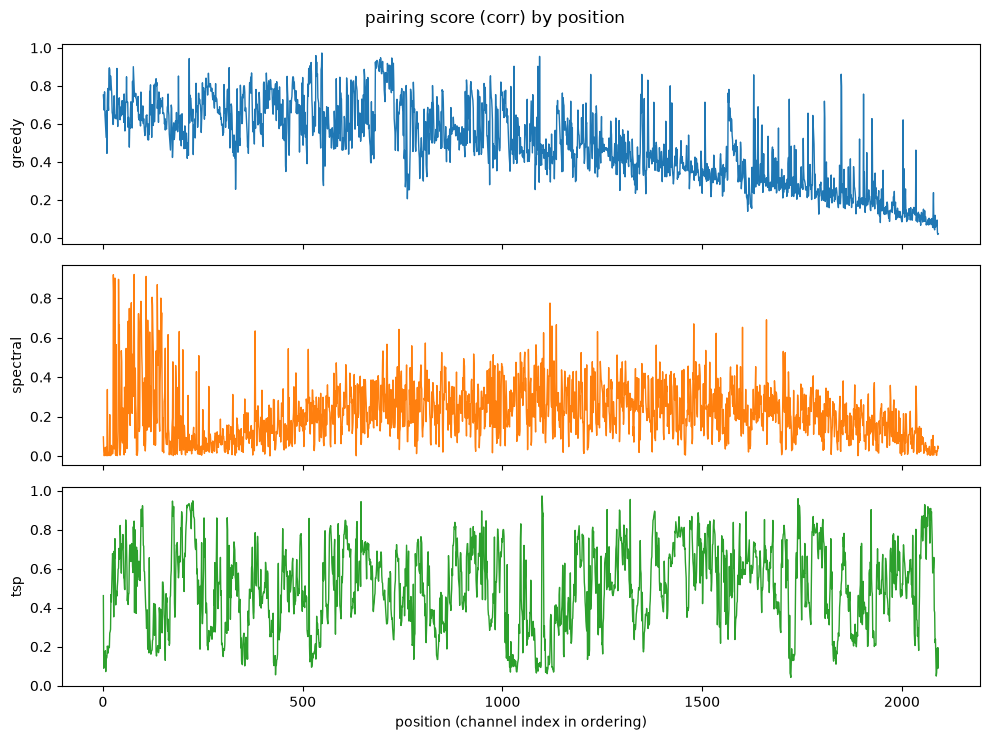

In [ ]:
#| eval: false
show_score_profile(C, {'greedy': order_g, 'spectral': order_s, 'tsp': order_t}, title=f"pairing score ({PAIRING}) by position")

Same scores, sorted independently within each row (most-correlated-left,
least-correlated-right) rather than left in positional order -- decouples
"how good is this method overall" from "where in the sequence does it hold up,"
which the plot above already answers.

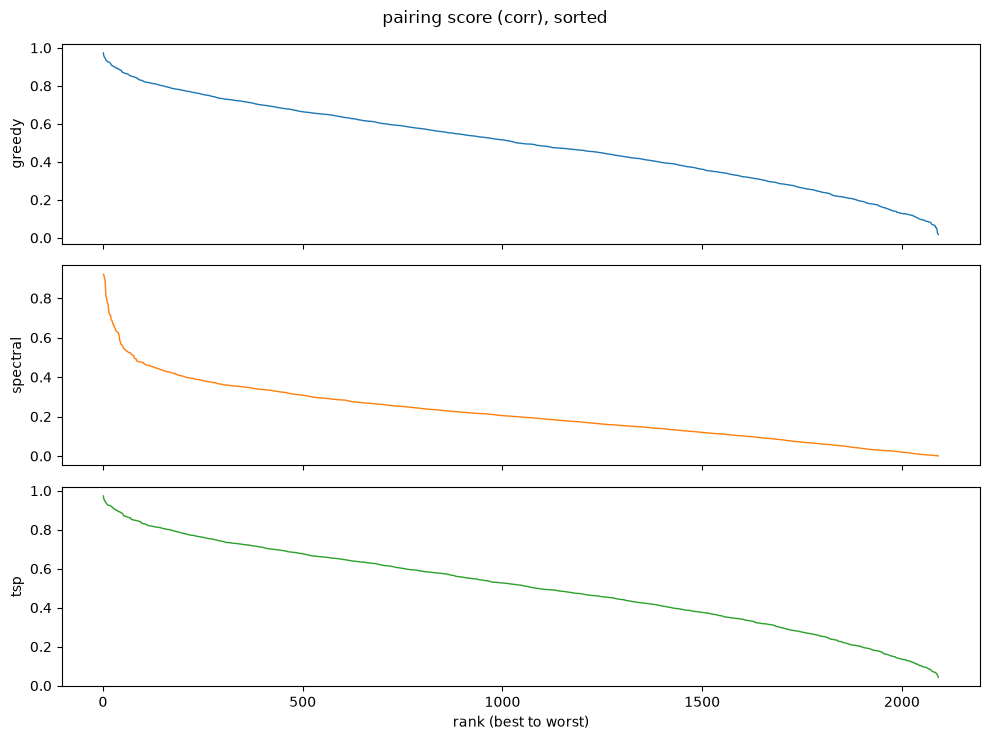

In [ ]:
#| eval: false
show_score_profile(C, {'greedy': order_g, 'spectral': order_s, 'tsp': order_t}, title=f"pairing score ({PAIRING}), sorted", sort_desc=True)

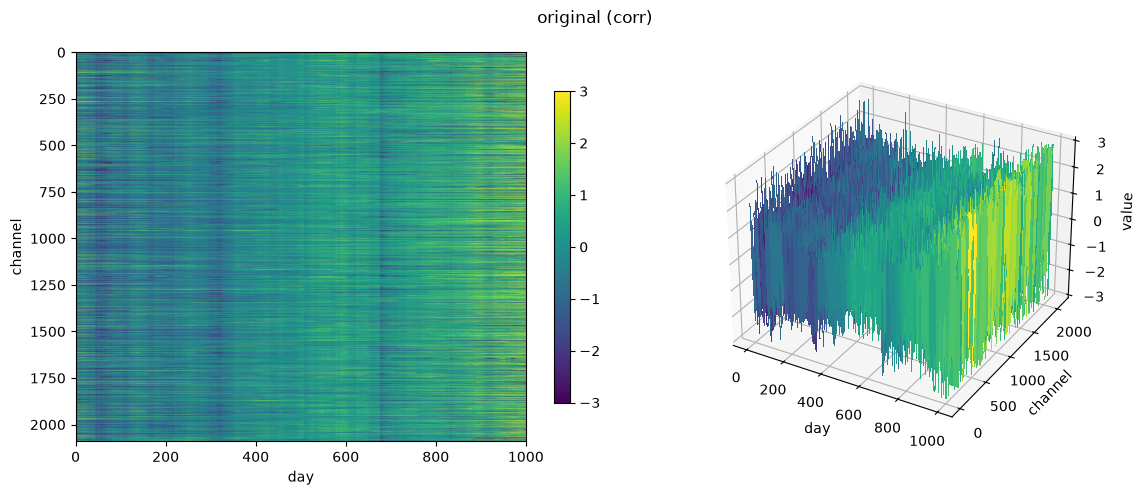

In [ ]:
#| eval: false
Zl = log_prices(prices)   # already on DEVICE; `show` moves to CPU at the matplotlib edge
show(Zl, f'original ({PAIRING})')

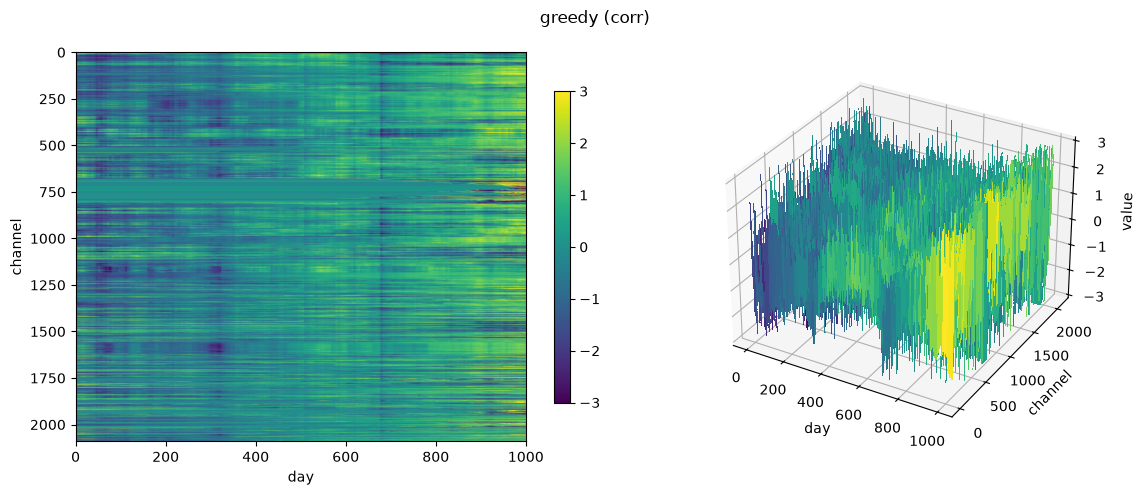

In [ ]:
#| eval: false
show(Zl[order_g], f'greedy ({PAIRING})')

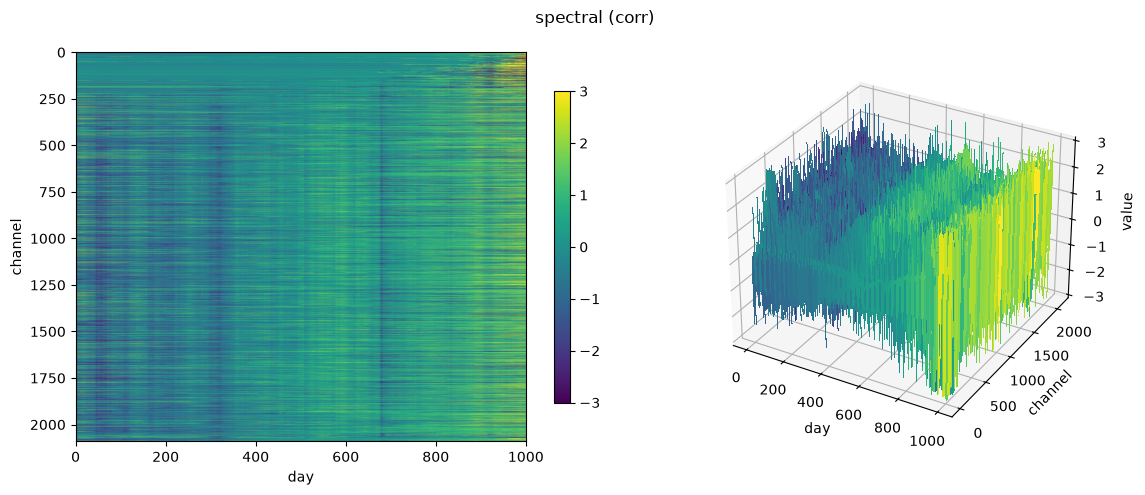

In [ ]:
#| eval: false
show(Zl[order_s], f'spectral ({PAIRING})')

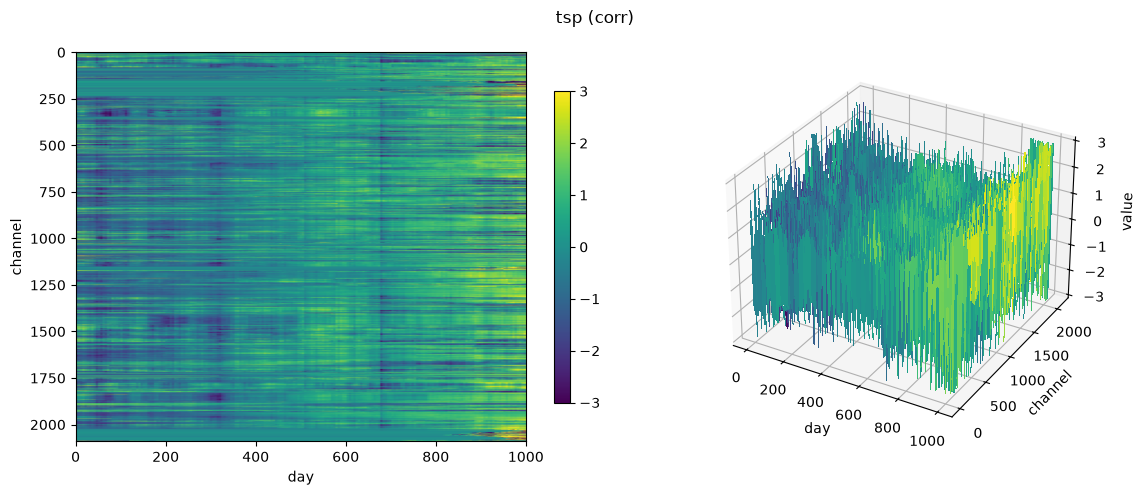

In [ ]:
#| eval: false
show(Zl[order_t], f'tsp ({PAIRING})')

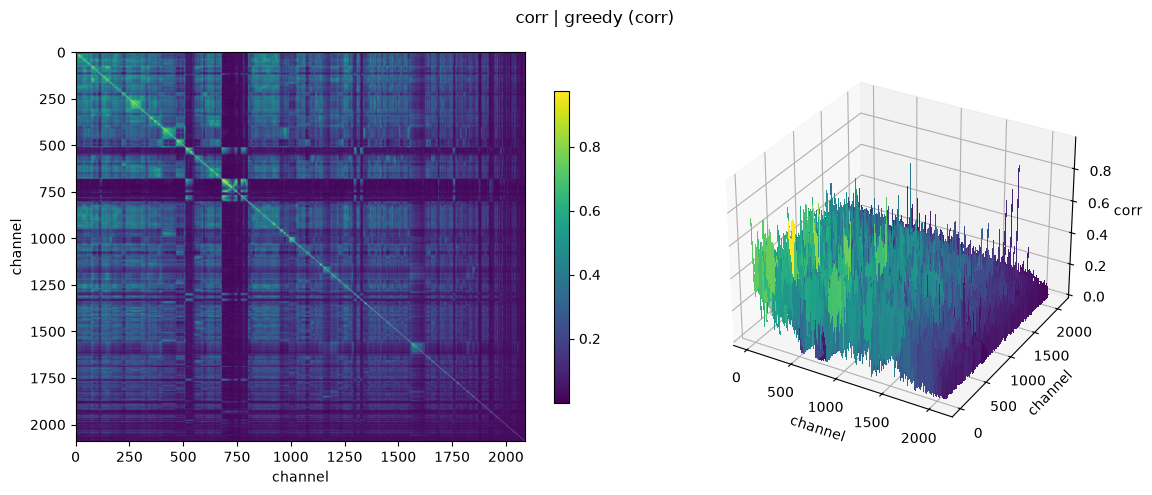

In [ ]:
#| eval: false
show_corr(C, order_g, f'corr | greedy ({PAIRING})')

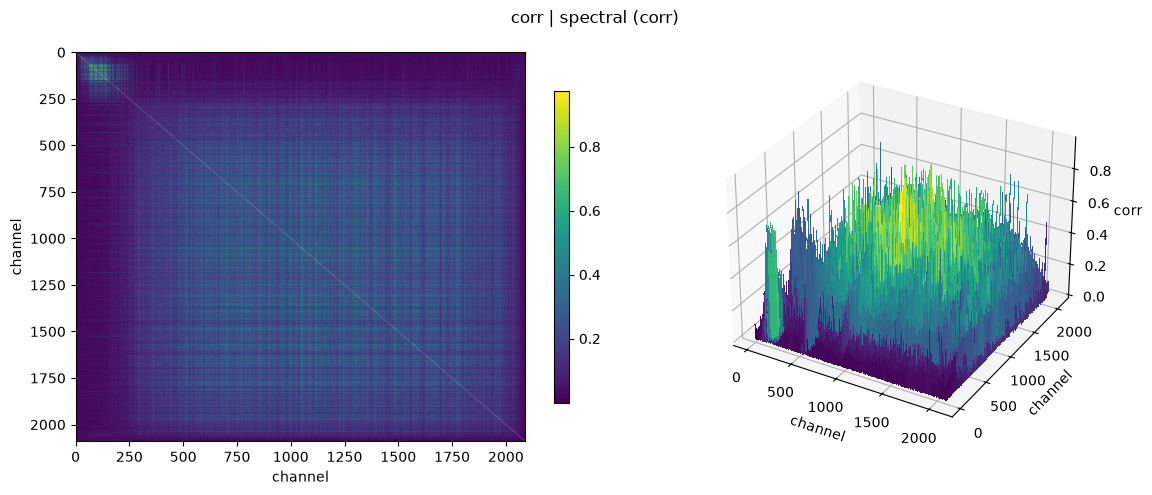

In [ ]:
#| eval: false
show_corr(C, order_s, f'corr | spectral ({PAIRING})')

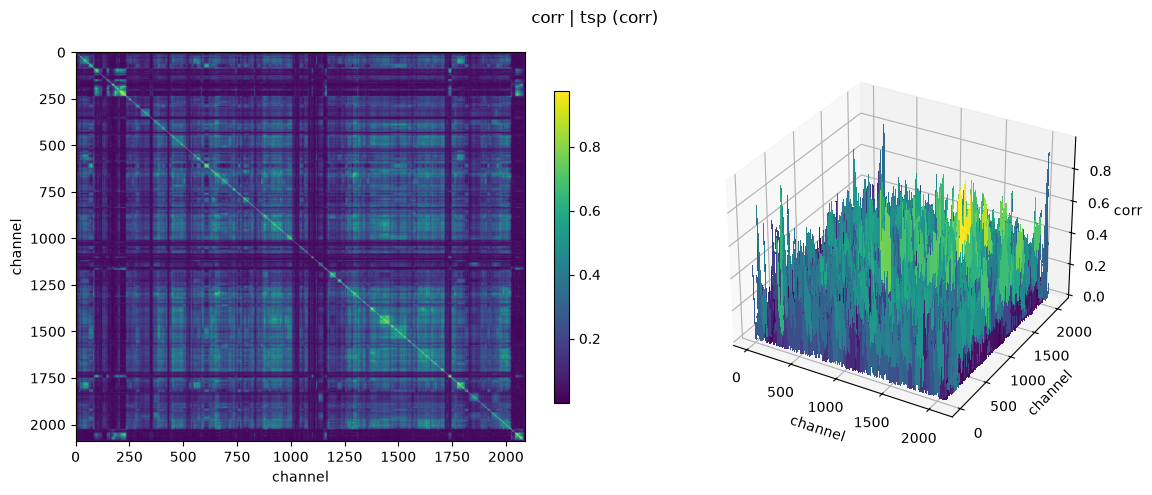

In [ ]:
#| eval: false
show_corr(C, order_t, f'corr | tsp ({PAIRING})')

# Benchmark: which pairing + which algorithm?

Everything above is a single pass over the full window -- fine for seeing what
each method *does*, but one number from one window isn't enough to choose
between methods whose scores differ by a few percent. This section resamples:
many random time windows, all 6 combinations (2 pairings x 3 algorithms)
evaluated on each, accumulated until a preference is clear.

**Train/validation split.** Each trial fits the ordering on one time window and
scores it on a *disjoint* one. This matters more than it might seem: `tsp`
optimizes the distance matrix that `roughness` is derived from, so scoring on
the same window it fit would make `tsp` win semi-tautologically -- it would be
grading its own objective. The held-out score instead asks the question we
actually care about: does this ordering capture channel structure that
**persists into a period it never saw**? That's what determines whether an
ordering is worth reusing going forward. In-sample is reported alongside it,
both because it's cheap (fitting dominates; evaluating a second window is
nearly free) and because a large in-sample/held-out gap is itself the signal
that a method is overfitting the window rather than finding real structure.

**Weighting by window length**, as requested -- longer fit windows give more
reliable correlation estimates, so they carry more weight in the mean.

Run over many crops, this is **repeated random subsampling cross-validation**
(Monte Carlo CV) -- splits drawn at random each trial, rather than partitioned
into fixed non-overlapping folds the way k-fold does. Because all 6 combos are
scored on the *identical* split every trial, the comparison is paired, which is
what makes differences of a few percent detectable at all.

Two summary statistics, because they answer different questions and can
disagree:

- **Weighted mean roughness** -- absolute quality, but comparable across trials
  only to the extent that different windows are equally "hard."
- **Win rate** -- how often a combo had the lowest roughness *within* a trial.
  Since all 6 combos see the identical window every trial, this is a paired,
  rank-based comparison, immune to some windows simply being noisier than
  others. This is usually the more trustworthy of the two.

In [ ]:
#| export
ALGOS = {
    "greedy":   lambda C, D: greedy_order(C, start=0),
    "spectral": lambda C, D: spectral_order(C, anchor=0),
    "tsp":      lambda C, D: two_opt(D, greedy_edge_order(D)),
}
PAIRINGS = ["corr", "xcorr"]

In [ ]:
assert set(ALGOS) == {"greedy", "spectral", "tsp"}
assert PAIRINGS == ["corr", "xcorr"]
# each entry must be callable with the (C, D) signature the trial loop uses
C_ = torch.tensor([[1.0, 0.9, 0.1], [0.9, 1.0, 0.8], [0.1, 0.8, 1.0]])
D_ = corr_to_dist(C_)
for name, fn in ALGOS.items():
    o = fn(C_, D_)
    assert sorted(o.tolist()) == [0, 1, 2], f"{name} did not return a valid permutation"
print("ok")

ok


In [ ]:
#| export
def sample_fit_eval(T, min_len, max_len, rng, min_eval=60):
    """Pick a random contiguous fit window, plus a DISJOINT eval window taken
    from whatever timeline remains on either side. Returns
    `((fit_start, fit_end), (eval_start, eval_end) or None)`."""
    L = int(rng.integers(min_len, max_len + 1))
    start = int(rng.integers(0, T - L + 1))
    fit = (start, start + L)
    segs = [s for s in ((0, start), (start + L, T)) if s[1] - s[0] >= min_eval]
    if not segs:
        return fit, None
    lo, hi = segs[int(rng.integers(0, len(segs)))]
    Le = min(L, hi - lo)
    es = int(rng.integers(lo, hi - Le + 1))
    return fit, (es, es + Le)

In [ ]:
import numpy as np

rng_ = np.random.default_rng(0)
for _ in range(200):
    fit, ev = sample_fit_eval(1000, 100, 500, rng_)
    assert 100 <= fit[1] - fit[0] <= 500
    assert 0 <= fit[0] < fit[1] <= 1000
    if ev is not None:
        # the whole point: fit and eval must not overlap
        assert ev[1] <= fit[0] or ev[0] >= fit[1], f"overlap! fit={fit} eval={ev}"
        assert 0 <= ev[0] < ev[1] <= 1000
print("ok")

ok


In [ ]:
#| export
def run_trial(returns, rng, min_len=120, max_len=None, xcorr_max_lag=20, min_var=1e-12):
    """One trial: crop a fit window, build all 6 (pairing, algo) orderings on
    it, and score each by roughness both in-sample and on a disjoint window.
    Channels degenerate *within this window* are dropped -- the same channel
    set is used for every combo, so the comparison stays paired."""
    T = returns.shape[1]
    max_len = max_len or int(0.8 * T)
    (fs, fe), ev = sample_fit_eval(T, min_len, max_len, rng)

    Rfit = returns[:, fs:fe]
    keep = Rfit.var(dim=1) > min_var
    Rfit = standardize(Rfit[keep])
    Rev = standardize(returns[keep][:, ev[0]:ev[1]]) if ev else None

    out = {}
    for pairing in PAIRINGS:
        C = build_corr(Rfit) if pairing == "corr" else build_xcorr(Rfit, max_lag=xcorr_max_lag)
        D = corr_to_dist(C)
        for algo, fn in ALGOS.items():
            order = fn(C, D)
            out[(pairing, algo)] = {
                "in_sample": roughness(Rfit, order),
                "held_out": roughness(Rev, order) if Rev is not None else float("nan"),
            }
    out["_meta"] = {"fit_len": fe - fs, "eval_len": (ev[1] - ev[0]) if ev else 0,
                    "n_channels": int(keep.sum())}
    return out

In [ ]:
import numpy as np

torch.manual_seed(0)
R_ = torch.randn(12, 400)
res_ = run_trial(R_, np.random.default_rng(1), min_len=80, max_len=200, xcorr_max_lag=3)

meta_ = res_.pop("_meta")
assert 80 <= meta_["fit_len"] <= 200
assert set(res_.keys()) == {(p, a) for p in PAIRINGS for a in ALGOS}    # all 6 combos present
for k, v in res_.items():
    assert v["in_sample"] > 0, f"{k} in_sample should be positive"
    assert not np.isnan(v["in_sample"])
print("ok:", meta_)

ok: {'fit_len': 137, 'eval_len': 128, 'n_channels': 12}


In [ ]:
#| export
def run_benchmark(returns, n_trials=20, results=None, seed=None, min_len=120,
                   max_len=None, xcorr_max_lag=20, progress=True):
    """Run `n_trials` independent trials, appending to `results` so the
    benchmark is resumable -- call it again with the same list to keep
    accumulating rather than starting over."""
    results = [] if results is None else results
    rng = np.random.default_rng(seed)
    it = tqdm(range(n_trials), desc="benchmark trials") if progress else range(n_trials)
    for _ in it:
        results.append(run_trial(returns, rng, min_len=min_len, max_len=max_len,
                                  xcorr_max_lag=xcorr_max_lag))
    return results

In [ ]:
torch.manual_seed(0)
R_ = torch.randn(10, 300)
res_ = run_benchmark(R_, n_trials=2, seed=0, min_len=80, max_len=150,
                      xcorr_max_lag=2, progress=False)
assert len(res_) == 2
res_ = run_benchmark(R_, n_trials=3, results=res_, seed=1, min_len=80, max_len=150,
                      xcorr_max_lag=2, progress=False)
assert len(res_) == 5, "should APPEND to existing results, not restart"
print("ok")

ok


In [ ]:
#| export
def summarize_benchmark(results, metric="held_out", verbose=True):
    """Weighted-mean roughness (weight = fit-window length) and win rate per
    combo, ranked best-first. Returns a list of dicts."""
    combos = [k for k in results[0] if k != "_meta"]
    w_all = np.array([r["_meta"]["fit_len"] for r in results], dtype=float)

    rows = []
    for combo in combos:
        vals = np.array([r[combo][metric] for r in results], dtype=float)
        ok = ~np.isnan(vals)
        v, w = vals[ok], w_all[ok]
        if len(v) == 0:
            continue
        wmean = float((v * w).sum() / w.sum())
        # standard error of a weighted mean (weights treated as known)
        se = float(np.sqrt((w ** 2 * (v - wmean) ** 2).sum()) / w.sum())
        rows.append({"pairing": combo[0], "algo": combo[1], "mean": wmean,
                      "se": se, "n": int(ok.sum()), "wins": 0})

    # win rate: per trial, who had the lowest score -- a paired comparison,
    # so it is not distorted by some windows simply being harder than others
    for r in results:
        scored = [(c, r[c][metric]) for c in combos if not np.isnan(r[c][metric])]
        if not scored:
            continue
        best = min(scored, key=lambda t: t[1])[0]
        for row in rows:
            if (row["pairing"], row["algo"]) == best:
                row["wins"] += 1

    n_trials = len(results)
    for row in rows:
        row["win_rate"] = row["wins"] / n_trials if n_trials else float("nan")
    rows.sort(key=lambda d: d["mean"])

    if verbose:
        print(f"metric={metric!r}, {n_trials} trials  (lower roughness = better)\n")
        print(f"{'pairing':8s} {'algo':9s} {'weighted mean':>14s} {'+/- se':>9s} {'win rate':>9s}")
        for row in rows:
            print(f"{row['pairing']:8s} {row['algo']:9s} {row['mean']:14.5f} "
                  f"{row['se']:9.5f} {row['win_rate']:9.1%}")
        if len(rows) >= 2:
            a, b = rows[0], rows[1]
            gap = b["mean"] - a["mean"]
            pooled = float(np.hypot(a["se"], b["se"]))
            verdict = "clear" if gap > 2 * pooled else "NOT yet separated -- run more trials"
            print(f"\nbest: {a['pairing']}/{a['algo']}  "
                  f"(gap to runner-up {gap:.5f}, ~{gap / pooled:.1f} se) -> {verdict}")
    return rows

In [ ]:
# hand-built results: "b" is unambiguously better on every trial
fake = [
    {("corr", "greedy"): {"in_sample": 0.5, "held_out": 0.5},
     ("corr", "tsp"):    {"in_sample": 0.2, "held_out": 0.2},
     "_meta": {"fit_len": 100, "eval_len": 50, "n_channels": 10}},
    {("corr", "greedy"): {"in_sample": 0.6, "held_out": 0.6},
     ("corr", "tsp"):    {"in_sample": 0.3, "held_out": 0.3},
     "_meta": {"fit_len": 200, "eval_len": 50, "n_channels": 10}},
]
rows = summarize_benchmark(fake, verbose=False)
assert rows[0]["algo"] == "tsp"                       # ranked best-first
assert rows[0]["win_rate"] == 1.0                     # won every trial
assert rows[1]["win_rate"] == 0.0
# weighted mean: (0.2*100 + 0.3*200)/300 = 0.2667, NOT the unweighted 0.25
assert abs(rows[0]["mean"] - (0.2 * 100 + 0.3 * 200) / 300) < 1e-9
print("ok")

ok


## Run it

`run_benchmark` appends to whatever list you pass, so this is resumable: run a
small batch, look, then keep going. Each trial takes roughly 3 seconds (all 6
combos, ~2000 channels), so ~100 trials is around 5 minutes.

Read **`held_out`** to decide what to actually use going forward; compare it
against `in_sample` to see which methods are overfitting their fit window.

In [ ]:
#| eval: false
bench_results = run_benchmark(returns, n_trials=25, seed=0)   # returns is already on DEVICE
len(bench_results)

benchmark trials: 100%|███████████████████████████████████████████████████████████████| 25/25 [00:39<00:00,  1.59s/it]


25

In [ ]:
#| eval: false
_ = summarize_benchmark(bench_results, metric="held_out")
print()
_ = summarize_benchmark(bench_results, metric="in_sample")

metric='held_out', 25 trials  (lower roughness = better)

pairing  algo       weighted mean    +/- se  win rate
corr     tsp              0.77043   0.00747     80.0%
xcorr    tsp              0.77113   0.00752     20.0%
corr     greedy           0.77842   0.00759      0.0%
xcorr    greedy           0.77971   0.00765      0.0%
xcorr    spectral         0.96211   0.01216      0.0%
corr     spectral         0.96586   0.01140      0.0%

best: corr/tsp  (gap to runner-up 0.00071, ~0.1 se) -> NOT yet separated -- run more trials

metric='in_sample', 25 trials  (lower roughness = better)

pairing  algo       weighted mean    +/- se  win rate
corr     tsp              0.70807   0.00383    100.0%
xcorr    tsp              0.71512   0.00393      0.0%
corr     greedy           0.71607   0.00370      0.0%
xcorr    greedy           0.72265   0.00380      0.0%
xcorr    spectral         0.91566   0.00391      0.0%
corr     spectral         0.91718   0.00391      0.0%

best: corr/tsp  (gap to runner-u

Not separated yet? Re-run the cell below as many times as you like -- it keeps
appending to `bench_results`, so the estimate tightens with every batch.

In [ ]:
#| eval: false
bench_results = run_benchmark(returns, n_trials=25, results=bench_results)
_ = summarize_benchmark(bench_results, metric="held_out")

benchmark trials: 100%|███████████████████████████████████████████████████████████████| 25/25 [00:39<00:00,  1.60s/it]

metric='held_out', 50 trials  (lower roughness = better)

pairing  algo       weighted mean    +/- se  win rate
corr     tsp              0.75884   0.00616     84.0%
xcorr    tsp              0.75983   0.00617     16.0%
corr     greedy           0.76671   0.00627      0.0%
xcorr    greedy           0.76779   0.00636      0.0%
xcorr    spectral         0.94311   0.00945      0.0%
corr     spectral         0.94891   0.00862      0.0%

best: corr/tsp  (gap to runner-up 0.00099, ~0.1 se) -> NOT yet separated -- run more trials


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()